In [1]:
#import required lib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#install ucimlrepo
!pip install ucimlrepo


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
#isolation forest
from sklearn.ensemble import IsolationForest

from ucimlrepo import fetch_ucirepo 

In [6]:
#load the dataset
air_quality = fetch_ucirepo(id=360)
air_quality 

{'data': {'ids': None,
  'features':            Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  \
  0     3/10/2004  18:00:00     2.6         1360       150      11.9   
  1     3/10/2004  19:00:00     2.0         1292       112       9.4   
  2     3/10/2004  20:00:00     2.2         1402        88       9.0   
  3     3/10/2004  21:00:00     2.2         1376        80       9.2   
  4     3/10/2004  22:00:00     1.6         1272        51       6.5   
  ...         ...       ...     ...          ...       ...       ...   
  9352   4/4/2005  10:00:00     3.1         1314      -200      13.5   
  9353   4/4/2005  11:00:00     2.4         1163      -200      11.4   
  9354   4/4/2005  12:00:00     2.4         1142      -200      12.4   
  9355   4/4/2005  13:00:00     2.1         1003      -200       9.5   
  9356   4/4/2005  14:00:00     2.2         1071      -200      11.9   
  
        PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  \
  0              1046      

In [12]:
data = air_quality.data.features
data.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


In [14]:
df=data[['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']]
df


,CO(GT),C6H6(GT),NOx(GT),NO2(GT)
0,2.6,11.9,166,113
1,2.0,9.4,103,92
2,2.2,9.0,131,114
3,2.2,9.2,172,122
4,1.6,6.5,131,116
...,...,...,...,...
9352,3.1,13.5,472,190
9353,2.4,11.4,353,179
9354,2.4,12.4,293,175
9355,2.1,9.5,235,156


In [17]:
#parameters for isolation forest
n_estimators = 100 #number of trees in the forest
contamination = 0.1 #proportion of outliers in the dataset
sample_size = 256 #number of samples to draw from the dataset to train each tree
# random_state = 42 #random seed for reproducibility

In [18]:
#Train the isolation forest model
model = IsolationForest(n_estimators=n_estimators, 
                        contamination=contamination,
                        max_samples=sample_size,
                        random_state=42) 

In [21]:
model.fit(df)
#predict anomalies
anomaly_labels = model.predict(df)
anomaly_labels
#anomaly_labels will be 1 for normal data points and -1 for anomalies

#add anomaly labels to the dataframe
df['anomaly'] = anomaly_labels #add a new column 'anomaly' to the dataframe to store the predicted labels



C:\Users\sigan\AppData\Local\Temp\ipykernel_15148\1684720847.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['anomaly'] = anomaly_labels #add a new column 'anomaly' to the dataframe to store the predicted labels


In [22]:
df.head()

,CO(GT),C6H6(GT),NOx(GT),NO2(GT),anomaly
0,2.6,11.9,166,113,1
1,2.0,9.4,103,92,1
2,2.2,9.0,131,114,1
3,2.2,9.2,172,122,1
4,1.6,6.5,131,116,1


In [23]:
#check the number of anomalies detected
num_anomalies = df['anomaly'].value_counts()
print(num_anomalies)

anomaly
 1    8421
-1     936
Name: count, dtype: int64


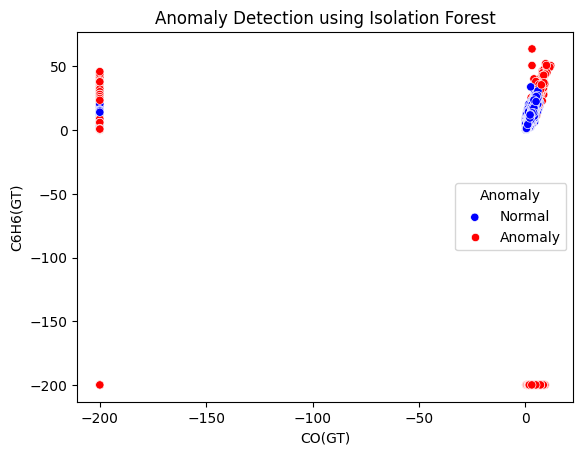

In [24]:
#visualize the anomalies
sns.scatterplot(data=df, x='CO(GT)', y='C6H6(GT)', hue='anomaly', palette={1: 'blue', -1: 'red'})
plt.title('Anomaly Detection using Isolation Forest')
plt.xlabel('CO(GT)')
plt.ylabel('C6H6(GT)')
plt.legend(title='Anomaly', labels=['Normal', 'Anomaly'])
plt.show()


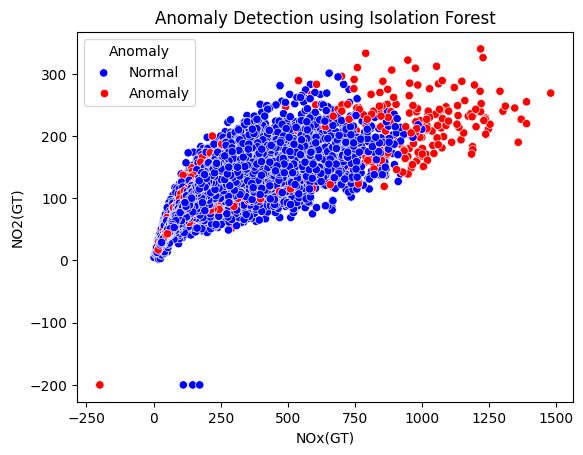

In [25]:
#plot 2 
sns.scatterplot(data=df, x='NOx(GT)', y='NO2(GT)', hue='anomaly', palette={1: 'blue', -1: 'red'})
plt.title('Anomaly Detection using Isolation Forest')
plt.xlabel('NOx(GT)')
plt.ylabel('NO2(GT)')
plt.legend(title='Anomaly', labels=['Normal', 'Anomaly'])
plt.show()


In [28]:
# Separate normal data points and anomalies
normal_data = df[df['anomaly'] == 1]
anomalies_data = df[df['anomaly'] == -1]

print("Normal Data Points:")
print(f"Count: {len(normal_data)}")
print(normal_data.head())

print("\n" + "="*50 + "\n")

print("Anomalies Detected:")
print(f"Count: {len(anomalies_data)}")
print(anomalies_data.head())


Normal Data Points:
Count: 8421
   CO(GT)  C6H6(GT)  NOx(GT)  NO2(GT)  anomaly
0     2.6      11.9      166      113        1
1     2.0       9.4      103       92        1
2     2.2       9.0      131      114        1
3     2.2       9.2      172      122        1
4     1.6       6.5      131      116        1


Anomalies Detected:
Count: 936
     CO(GT)  C6H6(GT)  NOx(GT)  NO2(GT)  anomaly
10   -200.0       1.3       21       34       -1
34   -200.0       1.1       21       32       -1
39   -200.0      22.1     -200     -200       -1
81      2.4       9.7     -200     -200       -1
111     8.1      36.7      478      149       -1


In [33]:
#saved model
import joblib
model_path = r"C:\aids\Unsupervised_Learning\anomaly detection\isolation_forest_model.pkl"
joblib.dump(model, model_path)

['C:\\aids\\Unsupervised_Learning\\anomaly detection\\isolation_forest_model.pkl']

In [34]:
import pandas as pd
from sklearn.ensemble import IsolationForest
import joblib

# Only original features
features = ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']

X = df[features]

# Train Isolation Forest
model = IsolationForest(
    contamination=0.05,
    random_state=42
)

model.fit(X)

# Confirm correct features
print("Model trained on:", model.feature_names_in_)

# Save model
joblib.dump(model, "isolation_forest_model.pkl")

print("✅ Model retrained and saved correctly")


Model trained on: ['CO(GT)' 'C6H6(GT)' 'NOx(GT)' 'NO2(GT)']
✅ Model retrained and saved correctly
